# Question 1
1. Simulate Sales Data using NumPy:
   - Create arrays for 100 sales transactions:
     - product_ids: Random integers from 1001 to 1010
     - quantities: Random integers between 1 and 5
     - prices: Random floats between 10 and 100 (rounded to 2 decimals)
     - dates: 100 random dates between Jan 1 and Jan 10, 2025

2. Create a DataFrame using Pandas:
   - Combine the arrays into a DataFrame called sales_df with columns:
     - ProductID, Quantity, Price, Date

3. Add Total Sale Column:
   - Create a new column: TotalSale = Quantity * Price

4. Introduce Missing Data:
   - Randomly set 5 Price values to NaN
   - Fill missing prices with the mean price

5. Group and Aggregate:
   - Group by ProductID and calculate:
     - Total quantity sold
     - Total revenue

6. Visualize using Matplotlib:
   - Bar chart: Total revenue per ProductID
   - Histogram: Distribution of TotalSale values
   - (Bonus) Subplot: One subplot with the bar chart, another with the histogram

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# Creating Arrays
np.random.seed(0)
product_ids=np.random.randint(1001, 1011, size=100)
quantities=np.random.randint(1, 6, size=100)
prices=np.round(np.random.uniform(10, 100, size=100), 2)
start=np.datetime64("2025-01-01")
end=np.datetime64("2025-02-10")
days=(end-start).astype(int)
date_generator=np.random.randint(0, days+1, size=100)
dates=start + date_generator

# Combining np arrays and creating dataframe
sales_df=pd.DataFrame({
    'ProductID': product_ids,
    'Quantity': quantities,
    'Price': prices,
    'Date': dates
})
print(sales_df)


    ProductID  Quantity  Price       Date
0        1006         1  18.96 2025-01-19
1        1001         4  41.71 2025-02-04
2        1004         3  52.23 2025-01-31
3        1004         3  85.70 2025-01-19
4        1008         1  91.42 2025-01-24
..        ...       ...    ...        ...
95       1001         3  70.74 2025-01-10
96       1002         5  34.92 2025-01-06
97       1003         4  25.74 2025-02-03
98       1005         4  73.40 2025-01-08
99       1003         1  51.68 2025-01-31

[100 rows x 4 columns]


In [3]:
# Creating a new Column
sales_df['Total Sales'] = sales_df['Quantity'] * sales_df['Price']
print(sales_df)

    ProductID  Quantity  Price       Date  Total Sales
0        1006         1  18.96 2025-01-19        18.96
1        1001         4  41.71 2025-02-04       166.84
2        1004         3  52.23 2025-01-31       156.69
3        1004         3  85.70 2025-01-19       257.10
4        1008         1  91.42 2025-01-24        91.42
..        ...       ...    ...        ...          ...
95       1001         3  70.74 2025-01-10       212.22
96       1002         5  34.92 2025-01-06       174.60
97       1003         4  25.74 2025-02-03       102.96
98       1005         4  73.40 2025-01-08       293.60
99       1003         1  51.68 2025-01-31        51.68

[100 rows x 5 columns]


In [4]:
# Setting 5 prices to nan
np.random.seed(0)
index=np.random.choice(100, size=5, replace=False)
sales_df.loc[index, 'Price'] = np.nan
print(sales_df)

print("\n\n Randomly added missing values:\n\n")

# filling those with mean value
sales_mean=sales_df['Price'].mean()
sales_df['Price']=sales_df['Price'].fillna(sales_mean)
print(sales_df)

    ProductID  Quantity  Price       Date  Total Sales
0        1006         1  18.96 2025-01-19        18.96
1        1001         4  41.71 2025-02-04       166.84
2        1004         3    NaN 2025-01-31       156.69
3        1004         3  85.70 2025-01-19       257.10
4        1008         1  91.42 2025-01-24        91.42
..        ...       ...    ...        ...          ...
95       1001         3  70.74 2025-01-10       212.22
96       1002         5  34.92 2025-01-06       174.60
97       1003         4  25.74 2025-02-03       102.96
98       1005         4  73.40 2025-01-08       293.60
99       1003         1  51.68 2025-01-31        51.68

[100 rows x 5 columns]


 Randomly added missing values:


    ProductID  Quantity      Price       Date  Total Sales
0        1006         1  18.960000 2025-01-19        18.96
1        1001         4  41.710000 2025-02-04       166.84
2        1004         3  57.471158 2025-01-31       156.69
3        1004         3  85.700000 2025-01-1

In [5]:
# Groupby product id and calculate total quantity sold and total revenue
grouped_sales=sales_df.groupby('ProductID').agg(Total_Quantity=('Quantity', 'sum'), Total_Revenue=('Total Sales', 'sum'))
print(grouped_sales)

           Total_Quantity  Total_Revenue
ProductID                               
1001                   25        1540.82
1002                   37        2191.34
1003                   15         808.38
1004                   43        2097.70
1005                   42        2803.93
1006                   29        1633.64
1007                   13         620.15
1008                   30        1690.35
1009                   21        1087.81
1010                   26        1496.62


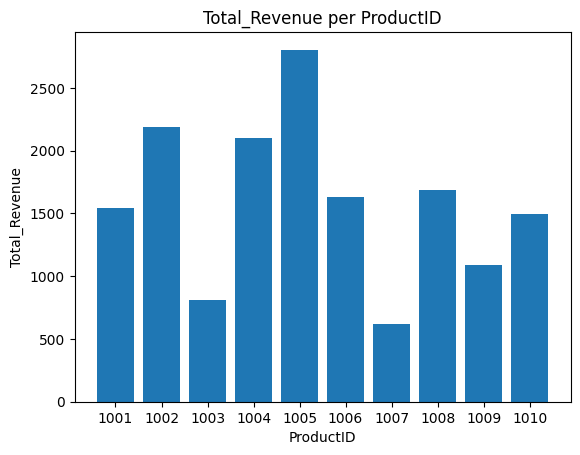

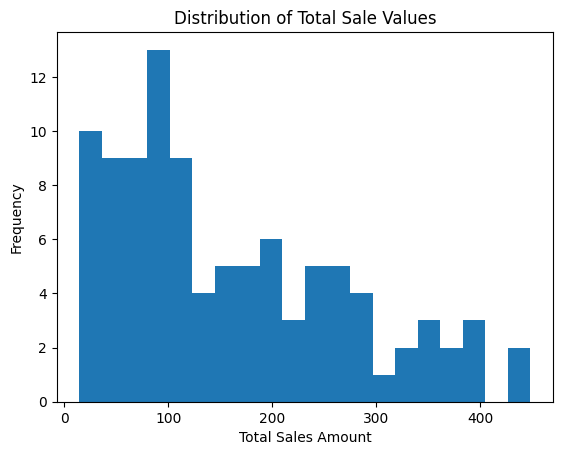

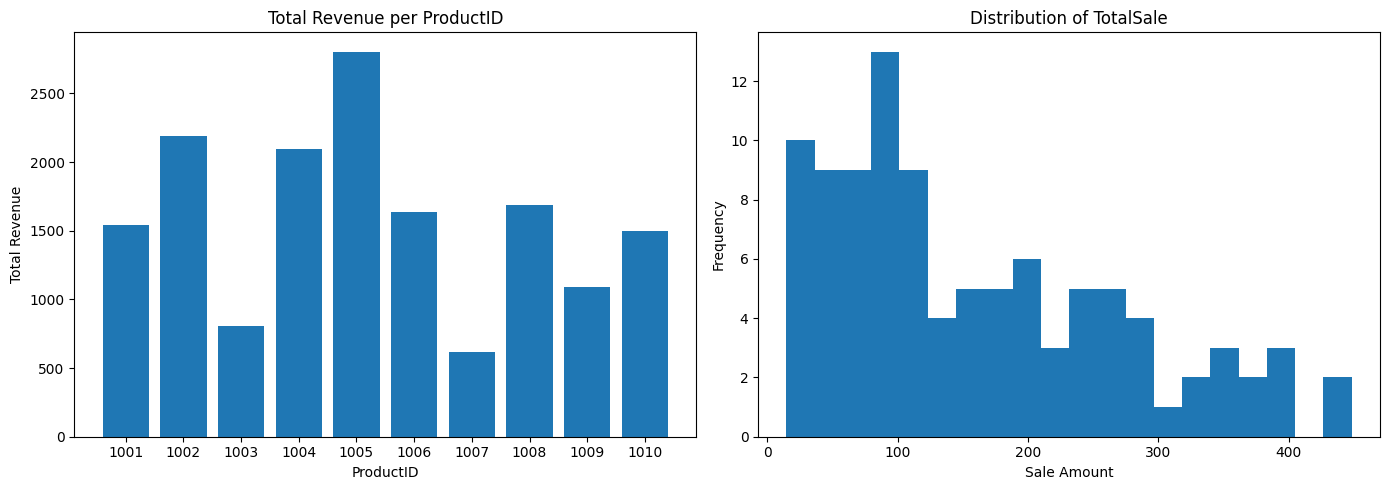

In [6]:
# Bar chart: Total revenue per ProductID
plt.figure()
plt.bar(grouped_sales.index, grouped_sales['Total_Revenue'])
plt.title('Total_Revenue per ProductID')
plt.xlabel('ProductID')
plt.ylabel('Total_Revenue')
plt.xticks(grouped_sales.index)
plt.show()
# Histogram: Distribution of TotalSale values
plt.figure()
plt.hist(sales_df['Total Sales'], bins=20)
plt.title('Distribution of Total Sale Values')
plt.xlabel('Total Sales Amount')
plt.ylabel('Frequency')         
plt.show()
# (Bonus) Subplot: One subplot with the bar chart, another with the histogram
fig, axes=plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(grouped_sales.index, grouped_sales["Total_Revenue"])
axes[0].set_title("Total Revenue per ProductID")
axes[0].set_xlabel("ProductID")
axes[0].set_ylabel("Total Revenue")
axes[0].set_xticks(grouped_sales.index)

# RIGHT: Histogram
axes[1].hist(sales_df["Total Sales"], bins=20)
axes[1].set_title("Distribution of TotalSale")
axes[1].set_xlabel("Sale Amount")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()


# Question 2
1. Generate Data (Pandas + NumPy)
    * Create a dataset of 500 employees with the following columns:
        * Employee_ID (1–500)
        * Department (Random choice: HR, IT, Finance, Sales)
        * Salary (10k to 50k)
        * Experience_Years (Random integers between 1–20)
        * Performance_Score (Random integers 1–5)
        * Randomly introduce missing values in 10% of Salary and Experience_Years.
2. Data Cleaning
    * Identify missing values
    * Fill missing Salary with the median of that department.
    * Fill missing Experience_Years with the overall mean.
3. Analysis
    * Group employees by Department and calculate:
    * Average Salary
    * Average Performance Score
    * Average Experience
4. Visualization (Matplotlib + Seaborn)
    * Create a bar chart showing average salary per department.
    * Create a boxplot of salaries across departments to check distribution.
    * Create a scatter plot of Experience_Years vs Salary, colored by Performance_Score.

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(0)
employee_id=np.arange(1, 501)
departments=np.random.choice(['HR', 'IT', 'Finance', 'Sales'], size=500)
salary=np.random.randint(10000, 50001, size=500).astype('float')
experience=np.random.randint(1, 21, size=500).astype('float')
performance=np.random.randint(1, 6, size=500)

missing_val=int(.10*500)
salary_missing=np.random.choice(500, size=50, replace=False)
exp_missing=np.random.choice(500, size=50, replace=False)

salary[salary_missing]=np.nan
experience[exp_missing]=np.nan

emp_df=pd.DataFrame({
    'Employee_ID': employee_id,
    'Department':departments,
    'Salary': salary,
    'Experience': experience,
    'Performance': performance
})
print(emp_df)

     Employee_ID Department   Salary  Experience  Performance
0              1         HR  38587.0         3.0            5
1              2      Sales  28231.0         9.0            2
2              3         IT  19724.0        11.0            5
3              4         HR  33314.0         6.0            1
4              5      Sales  10941.0         7.0            4
..           ...        ...      ...         ...          ...
495          496    Finance  35136.0         1.0            5
496          497      Sales  21463.0        18.0            3
497          498    Finance  29126.0        18.0            3
498          499         IT  14452.0         9.0            4
499          500    Finance  36450.0        10.0            2

[500 rows x 5 columns]


In [8]:
# Data Cleaning
print("Null values: \n", emp_df.isnull().sum())

dept_median=emp_df.groupby('Department')['Salary'].median()
emp_df['Salary']=emp_df['Salary'].fillna(emp_df['Department'].map(dept_median))
emp_df['Experience']=emp_df['Experience'].fillna(emp_df['Experience'].mean())

print("Null values: \n", emp_df.isnull().sum())

Null values: 
 Employee_ID     0
Department      0
Salary         50
Experience     50
Performance     0
dtype: int64
Null values: 
 Employee_ID    0
Department     0
Salary         0
Experience     0
Performance    0
dtype: int64


In [9]:
grouped=emp_df.groupby('Department').agg(Average_Salary=('Salary', 'mean'), Average_Performance=('Performance', 'mean')
                                        , Average_Exp=('Experience', 'mean')).reset_index()
print(grouped)

  Department  Average_Salary  Average_Performance  Average_Exp
0    Finance    32163.824324             3.045045    11.076517
1         HR    30177.456693             3.039370    10.241837
2         IT    30631.311475             2.991803    11.129071
3      Sales    29573.678571             2.971429    10.062238


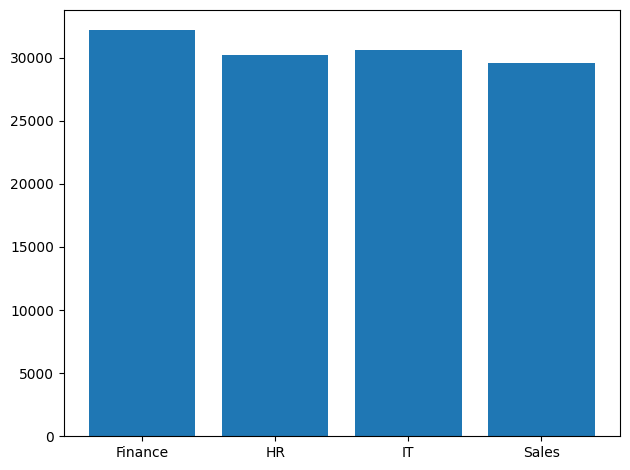

In [10]:
# Create a bar chart showing average salary per department.
plt.figure()
plt.bar(grouped['Department'], grouped['Average_Salary'])
plt.tight_layout()
plt.show()

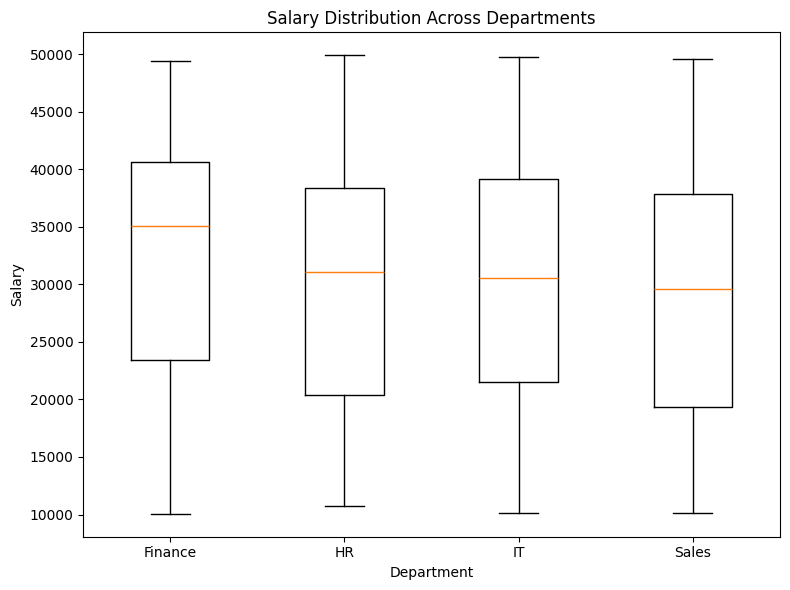

In [11]:
# Create a boxplot of salaries across departments to check distribution.
plt.figure(figsize=(8,6))

plt.boxplot(
    [
        emp_df[emp_df['Department'] == 'Finance']['Salary'],
        emp_df[emp_df['Department'] == 'HR']['Salary'],
        emp_df[emp_df['Department'] == 'IT']['Salary'],
        emp_df[emp_df['Department'] == 'Sales']['Salary']
    ],
    tick_labels=['Finance', 'HR', 'IT', 'Sales']
)

plt.title("Salary Distribution Across Departments")
plt.xlabel("Department")
plt.ylabel("Salary")
plt.tight_layout()
plt.show()

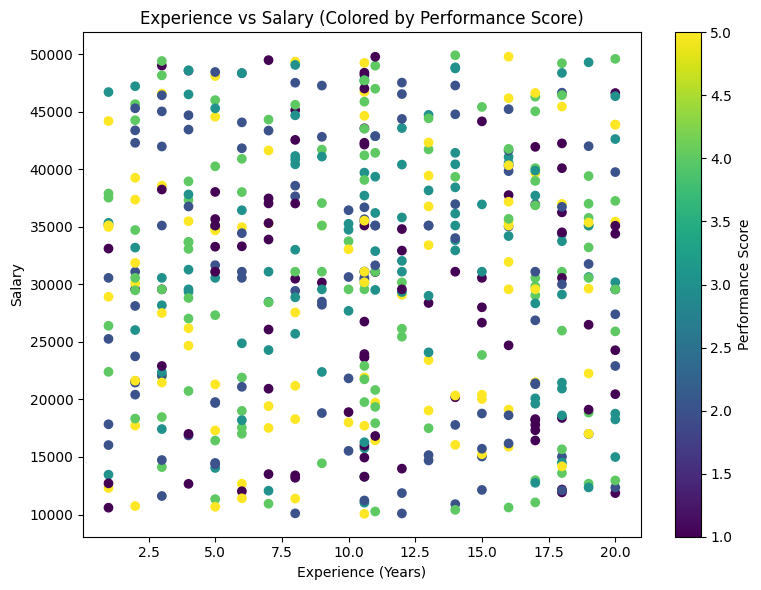

In [12]:
# Create a scatter plot of Experience_Years vs Salary, colored by Performance_Score.
plt.figure(figsize=(8,6))

plt.scatter(
    emp_df['Experience'],
    emp_df['Salary'],
    c=emp_df['Performance'],   # color by Performance Score
    cmap='viridis'             # colormap (you can change if you like)
)

plt.colorbar(label="Performance Score")  # legend for colors
plt.xlabel("Experience (Years)")
plt.ylabel("Salary")
plt.title("Experience vs Salary (Colored by Performance Score)")
plt.tight_layout()
plt.show()